# Simple Grid World: Policy Approximation

## Installation and Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [23]:
import numpy as np
np.set_printoptions(precision=2)

In [24]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

/home/mhahsler/github/Introduction_to_Reinforcement_Learning/common/gym-classics/gym_classics/__init__.py:87: UserWarning: gym-classics environments were already registered for gymnasium; additional calls to `register()` are ignored.
  warnings.warn("gym-classics environments were already registered for {}; "


## Define the L-Maze Grid World 

In [25]:
gym_env = gym.make('LMaze-v0')
env = gym_env.unwrapped

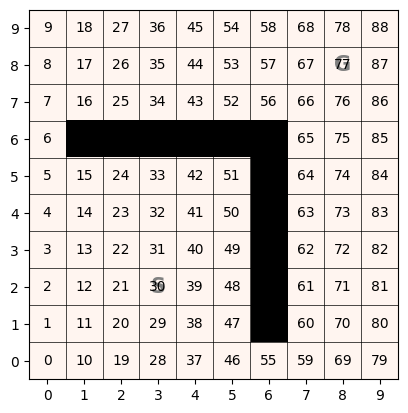

In [26]:
env.image()

## Policy Approximation: Linear Soft-Max In Action Preferences

Use Fourier-basis transformation and set up state-action features.

In [27]:
from gym_classics.algorithms.linear_approximation import transformation_fourier_basis, active_weights

trans_fb = transformation_fourier_basis(min = np.array([0,0]), max = env.dims, order=2)

def state_features(s,env):
    return trans_fb(env.decode(s))

In [28]:
def state_action_features(s,a,env):
    s = state_features(s,env)
    x = np.zeros(1+len(s)*env.action_space.n)
    x[active_weights(a, len(s)-1)] = s
    return x

Define the preference function $h(s,a,\bf{\theta})=\bf{\theta}^\top \bf{x}(s,a)$

In [29]:
def h(s,a,theta,env):
    return np.dot(theta, state_action_features(s,a,env))

Soft-max transformation from scores to a probability distribution: $\pi(s,a,\theta) = \frac{e^{h(s,a,\bf{\theta})}}{\sum_b h(s,a,\bf{\theta})}$

In [30]:
def pi(s,theta,env):
    hs = np.array([h(s,a,theta,env) for a in range(env.action_space.n)])
    exp_hs = np.exp(hs)
    return exp_hs / np.sum(exp_hs)

Check with a random weight vector.

In [31]:
theta = np.random.rand(1+len(state_features(0, env))*env.action_space.n)
theta

array([0.23, 0.2 , 0.82, 0.67, 0.89, 0.5 , 0.66, 0.6 , 0.79, 0.75, 0.18,
       0.42, 0.48, 0.76, 0.59, 0.33, 0.9 , 0.16, 0.71, 0.3 , 0.11, 0.44,
       0.85, 0.6 , 0.54, 0.37, 0.53, 0.91, 0.05, 0.14, 0.88, 0.46, 0.46,
       0.9 , 0.2 , 0.87, 0.88])

Calculate the preferences score for all actions for state 0.

In [32]:
[h(0,a,theta, env) for a in range(env.action_space.n)] 

[np.float64(5.348175425102685),
 np.float64(4.642423853526947),
 np.float64(3.9371557048783026),
 np.float64(4.0312265768446345)]

Calculate $\pi(s,a,\theta)$ for all actions in state $s=0$

In [33]:
pi(0,theta,env)

array([0.5 , 0.25, 0.12, 0.13])

## REINFORCE

![Pseudocode REINFORCE](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_REINFORCE.png)

We need to sample following a stochastic policy.

In [34]:
def sample_episode_policy(env, pi, theta, max_episode_length=1000):
    """
    Sample an episode using the policy defined by pi and theta.
    Returns a list of (state, action, reward) tuples.
    """
    s, _ = env.reset()
    episode_data = []
    
    for t in range(max_episode_length):
        a = np.random.choice(range(env.action_space.n), p=pi(s,theta,env))
        next_s, r, done, _, _ = env.step(a)
        episode_data.append((s, a, r, next_s))
        s = next_s
        
        if done:
            break
    
    return episode_data


In [35]:
episode_data = sample_episode_policy(env, pi, theta)
episode_data

[(30, np.int64(3), 0.0, 21),
 (21, np.int64(0), 0.0, 22),
 (22, np.int64(1), 0.0, 31),
 (31, np.int64(1), 0.0, 40),
 (40, np.int64(3), 0.0, 31),
 (31, np.int64(1), 0.0, 40),
 (40, np.int64(0), 0.0, 41),
 (41, np.int64(3), 0.0, 32),
 (32, np.int64(1), 0.0, 41),
 (41, np.int64(3), 0.0, 32),
 (32, np.int64(1), 0.0, 41),
 (41, np.int64(1), 0.0, 50),
 (50, np.int64(1), 0.0, 50),
 (50, np.int64(3), 0.0, 41),
 (41, np.int64(3), 0.0, 32),
 (32, np.int64(3), 0.0, 23),
 (23, np.int64(3), 0.0, 14),
 (14, np.int64(1), 0.0, 23),
 (23, np.int64(3), 0.0, 14),
 (14, np.int64(2), 0.0, 13),
 (13, np.int64(3), 0.0, 3),
 (3, np.int64(3), 0.0, 3),
 (3, np.int64(3), 0.0, 3),
 (3, np.int64(3), 0.0, 3),
 (3, np.int64(1), 0.0, 13),
 (13, np.int64(3), 0.0, 3),
 (3, np.int64(3), 0.0, 3),
 (3, np.int64(0), 0.0, 4),
 (4, np.int64(2), 0.0, 3),
 (3, np.int64(0), 0.0, 4),
 (4, np.int64(3), 0.0, 4),
 (4, np.int64(3), 0.0, 4),
 (4, np.int64(3), 0.0, 4),
 (4, np.int64(3), 0.0, 4),
 (4, np.int64(3), 0.0, 4),
 (4, np.int6

Implement the REINFORCE algorithm. The gradient of the policy for linear approximation is proportional to  $\nabla ln\ \pi(s,a,\bf{\theta}) =   \bf{x}(s,a) - \sum_b \pi(b|s,\bf{\theta}) \bf{x}(s,b)$

In [36]:
from tqdm import tqdm

def REINFORCE(
    env,
    n,
    alpha,
    gamma,
    theta = None,
    max_episode_length=1000,
    verbose=False,
    history=False
    ):
    
    if theta is None:
        theta = np.zeros(1+len(state_features(0, env))*env.action_space.n)
    
    if history:
        returns = []        
        ep_lens = []
        thetas = []
        thetas.append(theta.copy())
        
    for episode in tqdm(range(n), desc="Episodes", disable=verbose):
        if verbose:
            print(f"Episode {episode+1}/{n}")
        
        episode_data = sample_episode_policy(env, pi, theta, max_episode_length)
        
        for t in range(len(episode_data)):
            #print(episode_data[t])
        
            G = np.sum([e[2] for e in episode_data[t:]] * (gamma ** np.arange(len(episode_data[t:]))))
            if history and t == 0:
                returns.append(G)   

            s,a,r,next_s = episode_data[t]
            
            # ln policy gradient= x(s,a)- sum_b pi(b|s,theta) x(s,b)
            grad_log_pi = state_action_features(s, a, env) - sum([pi(s, theta, env)[b] * state_action_features(s, b, env) for b in range(env.action_space.n)])
            
            if verbose: 
                print (f"t: {t}, G: {G:.2f}, grad_log_pi: {grad_log_pi}")
            
            theta += alpha * (gamma**t) * G * grad_log_pi
            
        if history:
            thetas.append(theta.copy())
            ep_lens.append(len(episode_data))
            
    if history:
        return theta, {'thetas': thetas, 'returns': returns, 'ep_lens': ep_lens}
       
    return theta

In [37]:
theta, history = REINFORCE(env, n=1000, alpha=0.1, gamma=0.99, history=True)

Episodes: 100%|██████████| 1000/1000 [00:11<00:00, 84.61it/s]


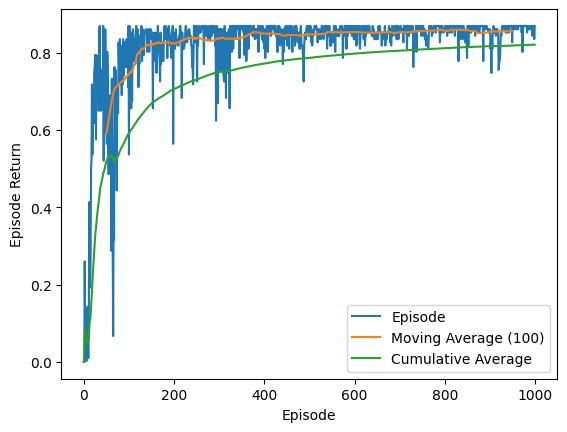

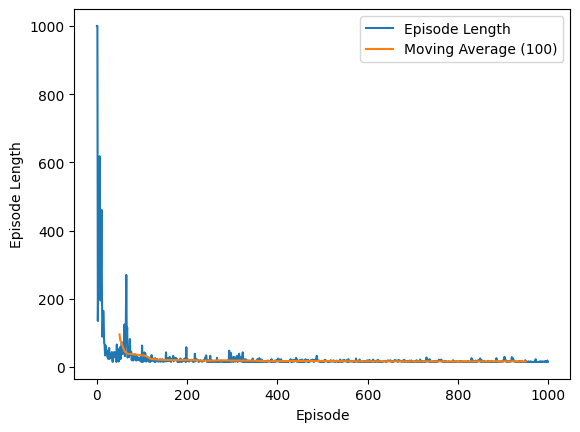

In [38]:
from gym_classics.performance import plot_returns, plot_ep_lens
plot_returns(history['returns'])
plot_ep_lens(history['ep_lens'])

Note: MC produces initially high variance.

## The Learned Policy

In [39]:
pol = [pi(s, theta,env) for s in range(env.observation_space.n)]
pol

[array([2.81e-03, 9.96e-01, 6.35e-09, 7.75e-04]),
 array([5.41e-03, 9.92e-01, 7.17e-08, 2.99e-03]),
 array([2.71e-02, 8.77e-01, 4.05e-05, 9.61e-02]),
 array([0.02, 0.08, 0.02, 0.88]),
 array([0.  , 0.  , 0.36, 0.64]),
 array([1.29e-04, 3.30e-05, 8.37e-01, 1.63e-01]),
 array([7.48e-05, 2.88e-05, 8.93e-01, 1.07e-01]),
 array([4.31e-04, 7.01e-04, 7.47e-01, 2.51e-01]),
 array([0.  , 0.05, 0.31, 0.64]),
 array([0.01, 0.5 , 0.04, 0.45]),
 array([1.05e-03, 9.98e-01, 2.49e-08, 5.56e-04]),
 array([9.42e-04, 9.96e-01, 1.74e-06, 2.76e-03]),
 array([0.  , 0.88, 0.  , 0.12]),
 array([0.  , 0.03, 0.52, 0.45]),
 array([2.35e-05, 5.28e-05, 9.42e-01, 5.77e-02]),
 array([5.68e-06, 2.43e-06, 9.76e-01, 2.43e-02]),
 array([6.52e-04, 5.33e-04, 7.17e-01, 2.82e-01]),
 array([0.01, 0.05, 0.23, 0.71]),
 array([0.02, 0.61, 0.03, 0.34]),
 array([8.86e-05, 1.00e+00, 9.70e-07, 2.42e-04]),
 array([6.58e-05, 9.98e-01, 2.39e-04, 1.58e-03]),
 array([2.05e-04, 5.49e-01, 3.97e-01, 5.39e-02]),
 array([3.99e-06, 4.60e-04, 

Visualize the learned policy by showing the action with the highest probability. The probability is shown using the tile color. 
Closer to 1 means that the algorithm is more sure about the action. Smaller values means that the algorithms still would like to explore.

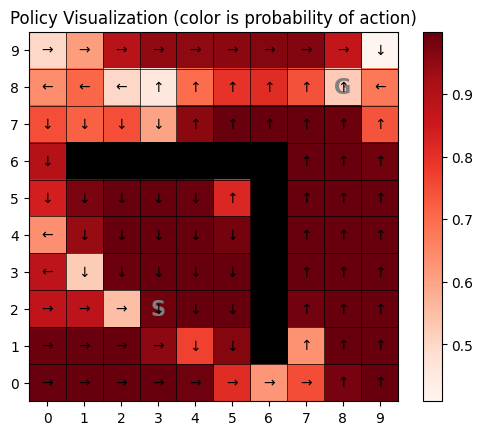

In [40]:
pol_discrete = np.argmax(pol, axis=1)
prob = np.max(pol, axis=1)
env.image(V=prob, policy=pol_discrete, title="Policy Visualization (color is probability of action)")

Visualize the found path using the highest probability action.

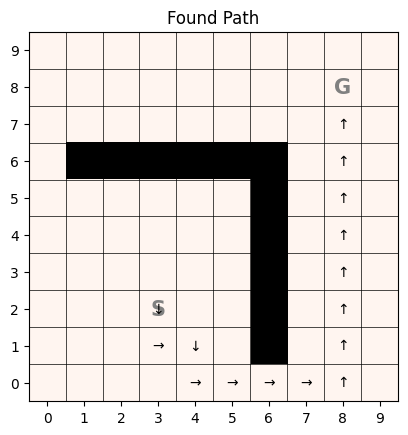

In [41]:
from gym_classics.algorithms.monte_carlo_methods import sample_episode

path = sample_episode(env, policy=pol_discrete, max_len=100)
env.image(policy=pol_discrete, episode=path, title='Found Path')


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)